# Basic Analysis of carousell_regression_numeric_y_price (1).csv



In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the dataset
file_path = 'C:/Users/ckltong/Downloads/carousell_regression_numeric_y_price_add_storage.csv'
df = pd.read_csv(file_path)
df.head()

,Price,Brand_Apple,Brand_Huawei,Brand_Samsung,Brand_Sony,Brand_Xiaomi,Is_iOS,Is_Android,Original_Price_HKD,Storage_GB,...,Price_Diff_Original_Minus_Price_HKD,Product_Origin_Imported,Product_Origin_Mixed,Product_Origin_Official,Product_Origin_Unknown,Storage_Tier_129-256,Storage_Tier_257-512,Storage_Tier_<=128,Storage_Tier_>512,Storage_Tier_Unknown
0,6200.0,1,0,0,0,0,1,0,10199.0,256.0,...,3999.0,0,0,1,0,1,0,0,0,0
1,2880.0,1,0,0,0,0,1,0,5999.0,512.0,...,3119.0,0,0,0,1,0,1,0,0,0
2,8500.0,1,0,0,0,0,1,0,7899.0,256.0,...,-601.0,1,0,0,0,1,0,0,0,0
3,11100.0,1,0,0,0,0,1,0,7899.0,512.0,...,-3201.0,0,0,1,0,0,1,0,0,0
4,6250.0,1,0,0,0,0,1,0,10199.0,256.0,...,3949.0,0,1,0,0,1,0,0,0,0


In [4]:
# Display summary statistics and info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7216 entries, 0 to 7215
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Price                                7216 non-null   float64
 1   Brand_Apple                          7216 non-null   int64  
 2   Brand_Huawei                         7216 non-null   int64  
 3   Brand_Samsung                        7216 non-null   int64  
 4   Brand_Sony                           7216 non-null   int64  
 5   Brand_Xiaomi                         7216 non-null   int64  
 6   Is_iOS                               7216 non-null   int64  
 7   Is_Android                           7216 non-null   int64  
 8   Original_Price_HKD                   7216 non-null   float64
 9   Storage_GB                           7216 non-null   float64
 10  Months_Since_Release                 7216 non-null   float64
 11  Condition_Percentage          

,Price,Brand_Apple,Brand_Huawei,Brand_Samsung,Brand_Sony,Brand_Xiaomi,Is_iOS,Is_Android,Original_Price_HKD,Storage_GB,...,Price_Diff_Original_Minus_Price_HKD,Product_Origin_Imported,Product_Origin_Mixed,Product_Origin_Official,Product_Origin_Unknown,Storage_Tier_129-256,Storage_Tier_257-512,Storage_Tier_<=128,Storage_Tier_>512,Storage_Tier_Unknown
count,7.216000e+03,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,...,7.216000e+03,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000,7216.000000
mean,6.117757e+04,0.550166,0.000139,0.404241,0.044484,0.000970,0.550166,0.449834,7746.432095,253.470759,...,-5.343114e+04,0.049612,0.002079,0.173365,0.774945,0.220344,0.110172,0.200111,0.000277,0.469096
std,4.711087e+06,0.497511,0.011772,0.490778,0.206183,0.031133,0.497511,0.497511,1548.455250,111.263349,...,4.711068e+06,0.217157,0.045549,0.378589,0.417648,0.414507,0.313126,0.400111,0.016647,0.499079
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1298.000000,12.000000,...,-3.999906e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7599.000000,256.000000,...,3.319000e+03,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.280000e+03,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,7899.000000,256.000000,...,5.099000e+03,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000e+03,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,8499.000000,256.000000,...,6.809500e+03,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,4.000000e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14998.000000,1000.000000,...,1.201800e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Eliminate outliers from the dataset using the IQR method on the target variable 'Price'
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()
print(f"Original dataset size: {df.shape[0]}")
print(f"Dataset size after outlier removal: {df_no_outliers.shape[0]}")

Original dataset size: 7216
Dataset size after outlier removal: 6998


## Testing Whether Features Show a Linear Relationship with Raw `Price`

To check whether each predictor has a roughly linear relationship with the raw response `Price`, we fit a **simple linear regression** for each numeric feature separately.

For each feature, we report:
- **Pearson correlation** with `Price`
- **Simple-regression $R^2$**
- **Slope p-value**
- a short interpretation label

We exclude `Price_Diff_Original_Minus_Price_HKD` here because it is derived from price and would create an artificial linear relationship.

Linear relationship test for each numeric feature vs Price:


,Feature,Pearson_r,Simple_R2,Slope,Slope_p_value,Interpretation
0,Storage_Tier_<=128,0.0231,0.0005,272076.1342,0.0497,Weak but significant linear signal
1,Post_Recency_Log,-0.0213,0.0005,-51416.9878,0.0702,No clear linear signal
2,Storage_GB,-0.0131,0.0002,-552.7506,0.2675,No clear linear signal
3,Condition_Score,-0.0127,0.0002,-46304.0527,0.2796,No clear linear signal
4,Is_Premium_Tier,0.0125,0.0002,117516.5099,0.2894,No clear linear signal
5,Original_Price_HKD,0.0125,0.0002,37.9472,0.2894,No clear linear signal
6,Brand_Apple,0.0113,0.0001,106640.7658,0.3388,No clear linear signal
7,Is_Android,-0.0113,0.0001,-106640.7658,0.3388,No clear linear signal
8,Is_iOS,0.0113,0.0001,106640.7658,0.3388,No clear linear signal
9,Storage_Tier_Unknown,-0.0105,0.0001,-99402.5360,0.3711,No clear linear signal


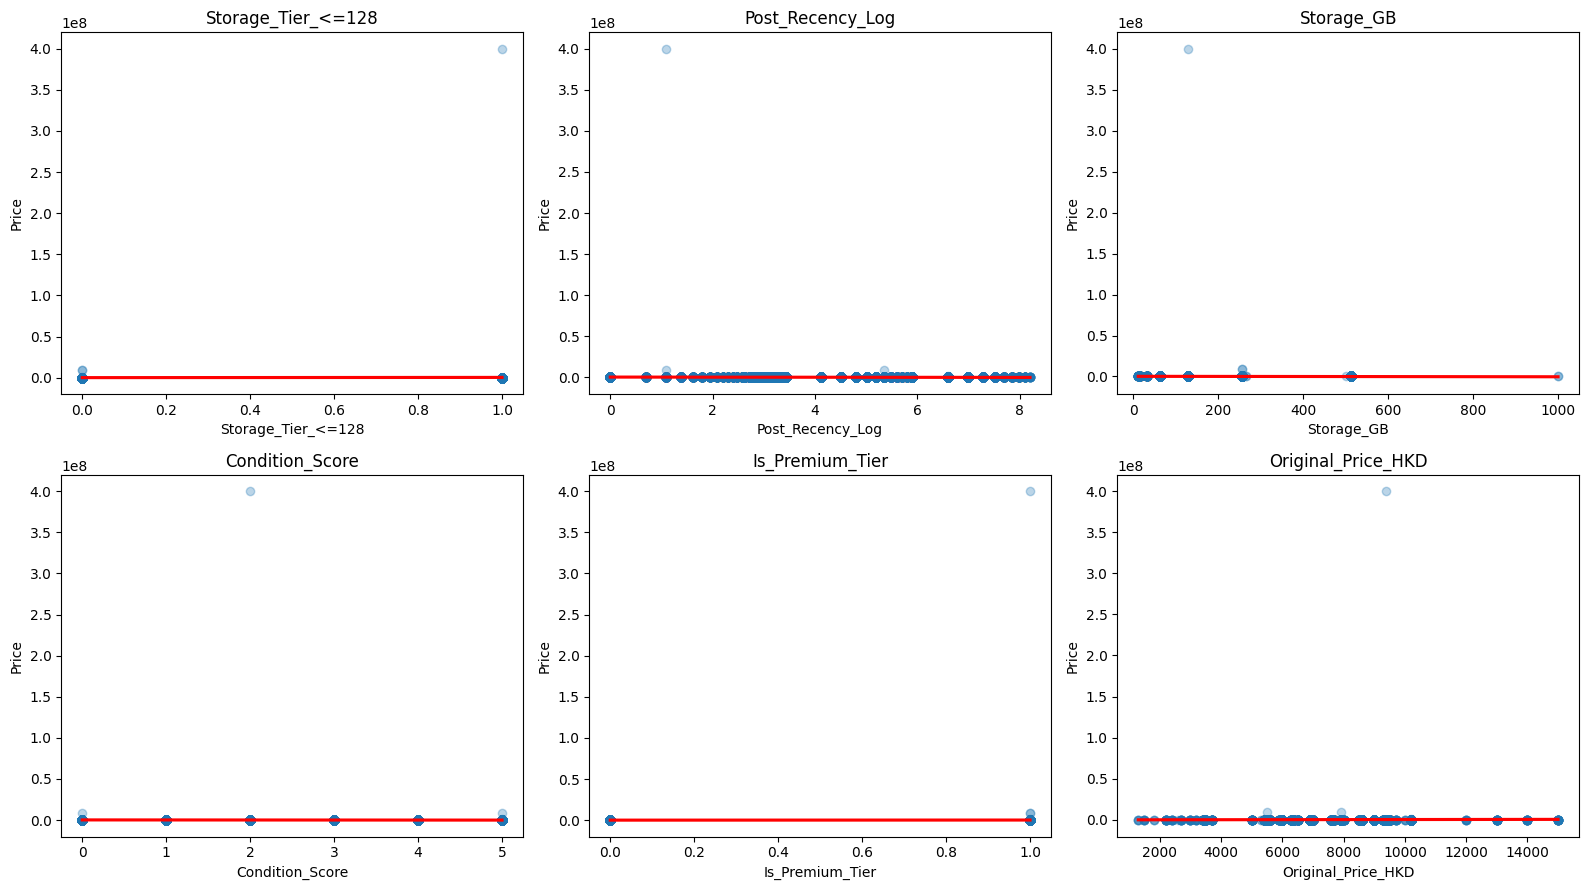

In [6]:
# Test whether each numeric feature shows a linear relationship with Price
from scipy import stats

price_target = df['Price']
excluded_features = ['Price', 'Price_Diff_Original_Minus_Price_HKD']
linear_test_features = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in excluded_features
 ]

linear_relationship_rows = []

for feature in linear_test_features:
    x = df[feature]
    valid_mask = np.isfinite(x) & np.isfinite(price_target)
    x_valid = x[valid_mask]
    y_valid = price_target[valid_mask]

    if x_valid.nunique() <= 1:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_valid, y_valid)

    if p_value < 0.05 and abs(r_value) >= 0.5:
        interpretation = 'Strong linear signal'
    elif p_value < 0.05 and abs(r_value) >= 0.3:
        interpretation = 'Moderate linear signal'
    elif p_value < 0.05:
        interpretation = 'Weak but significant linear signal'
    else:
        interpretation = 'No clear linear signal'

    linear_relationship_rows.append({
        'Feature': feature,
        'Pearson_r': r_value,
        'Simple_R2': r_value ** 2,
        'Slope': slope,
        'Slope_p_value': p_value,
        'Interpretation': interpretation
    })

linear_relationship_df = pd.DataFrame(linear_relationship_rows)
linear_relationship_df = linear_relationship_df.sort_values(by='Pearson_r', key=np.abs, ascending=False).reset_index(drop=True)
linear_relationship_df[['Pearson_r', 'Simple_R2', 'Slope', 'Slope_p_value']] = linear_relationship_df[['Pearson_r', 'Simple_R2', 'Slope', 'Slope_p_value']].round(4)

print('Linear relationship test for each numeric feature vs Price:')
display(linear_relationship_df)

# Visual check for the top 6 absolute correlations
top_linear_features = linear_relationship_df.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis, feature in zip(axes, top_linear_features):
    sns.regplot(data=df, x=feature, y='Price', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=axis)
    axis.set_title(feature)

for axis in axes[len(top_linear_features):]:
    axis.axis('off')

plt.tight_layout()
plt.show()

## Testing Whether Features Show a Linear Relationship with `log(Price + 1)`

Since raw price is highly skewed, we also test whether each feature has a more linear relationship with **`log(Price + 1)`**.

This uses the same simple one-feature-at-a-time regression idea as above, but with the transformed response. If the linear signal improves here, it suggests that the log transformation is more appropriate for regression analysis.

Linear relationship test for each numeric feature vs log(Price + 1):


,Feature,Pearson_r,Simple_R2,Slope,Slope_p_value,Interpretation
0,Months_Since_Release,-0.3174,0.1007,-0.0197,0.0000,Moderate linear signal
1,Days_Since_Posted,-0.3120,0.0973,-0.0007,0.0000,Moderate linear signal
2,Is_Premium_Tier,0.2741,0.0751,0.8232,0.0000,Weak but significant linear signal
3,Condition_Score,0.2733,0.0747,0.3169,0.0000,Weak but significant linear signal
4,Post_Recency_Log,-0.2723,0.0741,-0.2093,0.0000,Weak but significant linear signal
5,Storage_Tier_Unknown,-0.2463,0.0607,-0.7412,0.0000,Weak but significant linear signal
6,Is_Android,-0.2433,0.0592,-0.7344,0.0000,Weak but significant linear signal
7,Is_iOS,0.2433,0.0592,0.7344,0.0000,Weak but significant linear signal
8,Brand_Apple,0.2433,0.0592,0.7344,0.0000,Weak but significant linear signal
9,Original_Price_HKD,0.2432,0.0591,0.0002,0.0000,Weak but significant linear signal


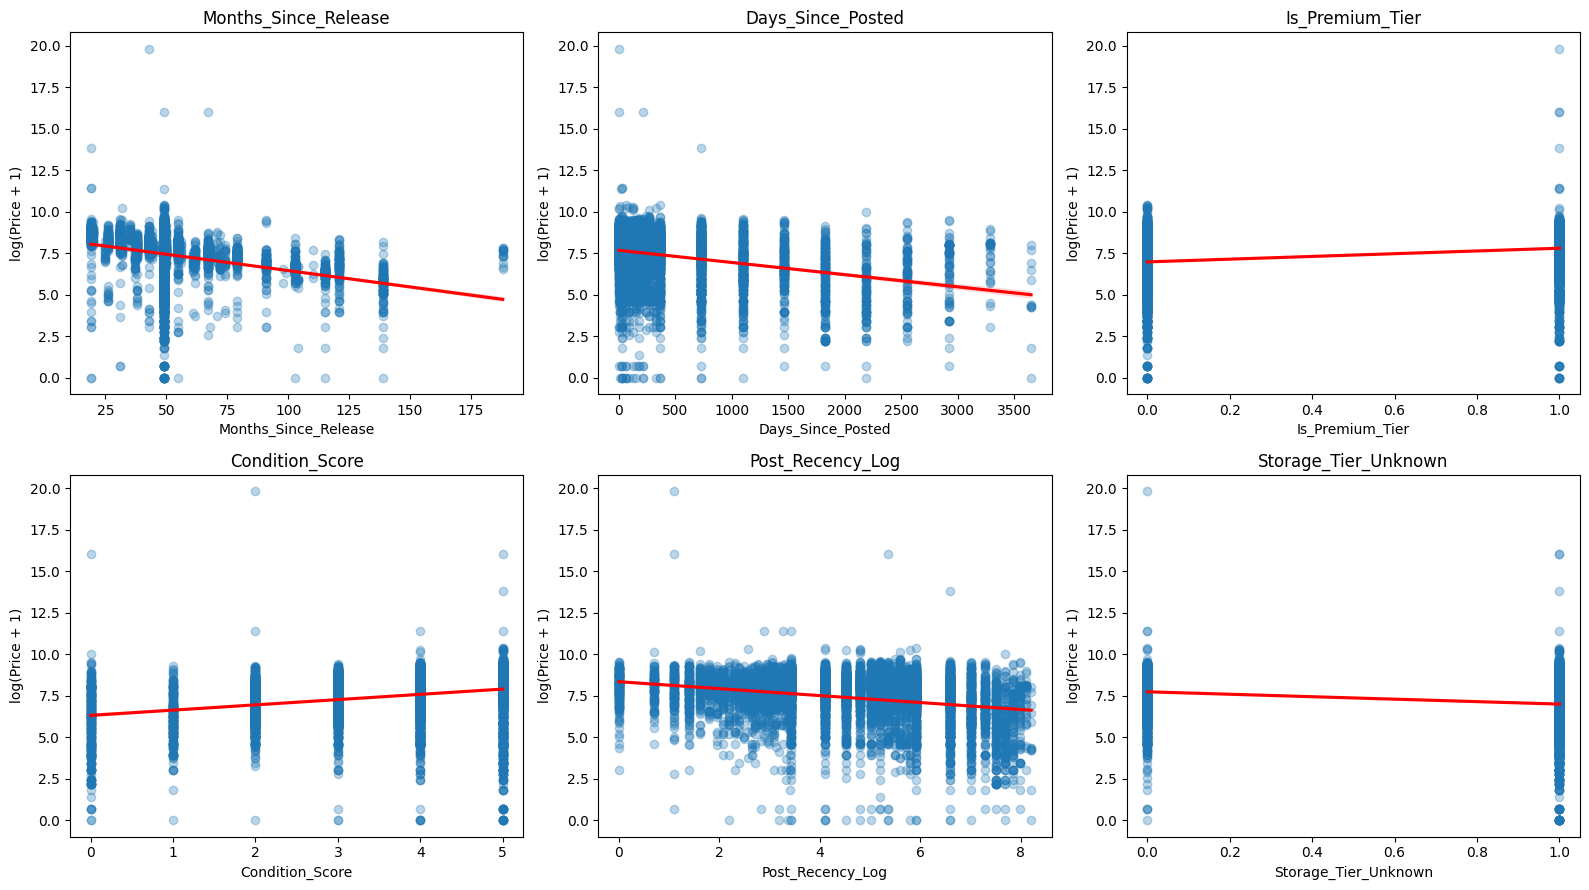

In [7]:
# Test whether each numeric feature shows a linear relationship with log(Price + 1)
log_price_target = np.log1p(df['Price'])
excluded_features_log = ['Price', 'Price_Diff_Original_Minus_Price_HKD']
linear_test_features_log = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in excluded_features_log
 ]

log_linear_relationship_rows = []

for feature in linear_test_features_log:
    x = df[feature]
    valid_mask = np.isfinite(x) & np.isfinite(log_price_target)
    x_valid = x[valid_mask]
    y_valid = log_price_target[valid_mask]

    if x_valid.nunique() <= 1:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_valid, y_valid)

    if p_value < 0.05 and abs(r_value) >= 0.5:
        interpretation = 'Strong linear signal'
    elif p_value < 0.05 and abs(r_value) >= 0.3:
        interpretation = 'Moderate linear signal'
    elif p_value < 0.05:
        interpretation = 'Weak but significant linear signal'
    else:
        interpretation = 'No clear linear signal'

    log_linear_relationship_rows.append({
        'Feature': feature,
        'Pearson_r': r_value,
        'Simple_R2': r_value ** 2,
        'Slope': slope,
        'Slope_p_value': p_value,
        'Interpretation': interpretation
    })

log_linear_relationship_df = pd.DataFrame(log_linear_relationship_rows)
log_linear_relationship_df = log_linear_relationship_df.sort_values(by='Pearson_r', key=np.abs, ascending=False).reset_index(drop=True)
log_linear_relationship_df[['Pearson_r', 'Simple_R2', 'Slope', 'Slope_p_value']] = log_linear_relationship_df[['Pearson_r', 'Simple_R2', 'Slope', 'Slope_p_value']].round(4)

print('Linear relationship test for each numeric feature vs log(Price + 1):')
display(log_linear_relationship_df)

# Visual check for the top 6 absolute correlations on the log scale
top_log_linear_features = log_linear_relationship_df.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis, feature in zip(axes, top_log_linear_features):
    sns.regplot(x=df[feature], y=np.log1p(df['Price']), scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=axis)
    axis.set_title(feature)
    axis.set_ylabel('log(Price + 1)')

for axis in axes[len(top_log_linear_features):]:
    axis.axis('off')

plt.tight_layout()
plt.show()

### Interpretation of the Linearity Test on `log(Price + 1)`

Compared with the raw-`Price` results above, the transformed response **`log(Price + 1)` shows much clearer linear relationships** with several predictors.

### Main findings
- **`Months_Since_Release`** and **`Days_Since_Posted`** show the strongest negative linear relationships with log-price.
- **`Is_Premium_Tier`**, **`Condition_Score`**, **`Post_Recency_Log`**, **`Original_Price_HKD`**, and **`Storage_GB`** also show meaningful but weaker linear trends.
- Many features that looked non-informative under raw price become statistically meaningful after the log transformation.

### Conclusion
This result supports the idea that **`log(Price + 1)` is a more appropriate response variable** for regression analysis than raw price. It reduces the effect of extreme values and reveals clearer linear patterns between predictors and the response.

## Feature Selection for `log(Price + 1)`

Why do feature selection here?

- It helps remove weak or redundant predictors.
- It makes the final regression model easier to interpret.
- It reduces the risk of overfitting.
- It ensures the selected predictors are aligned with the transformed response, not the raw price scale.

In this section, we combine:

- **Lasso** for linear sparse selection,
- **Random Forest** for non-linear importance,
- **Gradient Boosting** for another non-linear ranking.

We then build a **consensus ranking** to identify the strongest candidate predictors for the next modeling stage.

In [8]:
# Feature selection based on log(Price + 1)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

log_target = np.log1p(df['Price'])
log_feature_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in ['Price', 'Price_Diff_Original_Minus_Price_HKD']
]

X_log_select = df[log_feature_cols].copy()

# 1) Lasso importance on the log scale
log_lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=20000))
])
log_lasso_model.fit(X_log_select, log_target)

log_lasso_coef = pd.DataFrame({
    'Feature': log_feature_cols,
    'Lasso_Coefficient': log_lasso_model.named_steps['lasso'].coef_
})
log_lasso_coef['Abs_Lasso_Coefficient'] = log_lasso_coef['Lasso_Coefficient'].abs()
log_lasso_coef = log_lasso_coef.sort_values(by='Abs_Lasso_Coefficient', ascending=False).reset_index(drop=True)

# 2) Random Forest importance on the log scale
log_rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
log_rf_model.fit(X_log_select, log_target)
log_rf_importance = pd.DataFrame({
    'Feature': log_feature_cols,
    'RF_Importance': log_rf_model.feature_importances_
}).sort_values(by='RF_Importance', ascending=False).reset_index(drop=True)

# 3) Gradient Boosting importance on the log scale
log_gb_model = GradientBoostingRegressor(random_state=42)
log_gb_model.fit(X_log_select, log_target)
log_gb_importance = pd.DataFrame({
    'Feature': log_feature_cols,
    'GB_Importance': log_gb_model.feature_importances_
}).sort_values(by='GB_Importance', ascending=False).reset_index(drop=True)

# 4) Consensus ranking across the three methods
log_consensus_rows = []
for feature in log_feature_cols:
    lasso_rank = log_lasso_coef.index[log_lasso_coef['Feature'] == feature][0] + 1
    rf_rank = log_rf_importance.index[log_rf_importance['Feature'] == feature][0] + 1
    gb_rank = log_gb_importance.index[log_gb_importance['Feature'] == feature][0] + 1

    log_consensus_rows.append({
        'Feature': feature,
        'Lasso_Rank': lasso_rank,
        'RF_Rank': rf_rank,
        'GB_Rank': gb_rank,
        'Average_Rank': np.mean([lasso_rank, rf_rank, gb_rank])
    })

log_consensus_df = pd.DataFrame(log_consensus_rows).sort_values(by='Average_Rank').reset_index(drop=True)
log_consensus_df['Average_Rank'] = log_consensus_df['Average_Rank'].round(2)
rank_under_10_features = log_consensus_df.loc[
    log_consensus_df['Average_Rank'] < 10, 'Feature'
].tolist()

print('Top features from Lasso on log(Price + 1):')
display(log_lasso_coef.head(10))

print('Top features from Random Forest on log(Price + 1):')
display(log_rf_importance.head(10))

print('Top features from Gradient Boosting on log(Price + 1):')
display(log_gb_importance.head(10))

print('Consensus feature ranking for log(Price + 1):')
display(log_consensus_df)

print('Selected features with Average_Rank < 10:')
print(rank_under_10_features)
print(f'Total selected features: {len(rank_under_10_features)}')

Top features from Lasso on log(Price + 1):


,Feature,Lasso_Coefficient,Abs_Lasso_Coefficient
0,Months_Since_Release,-0.344829,0.344829
1,Brand_Apple,0.249448,0.249448
2,Condition_Score,0.184585,0.184585
3,Storage_GB,0.180847,0.180847
4,Storage_Tier_Unknown,-0.160015,0.160015
5,Is_Premium_Tier,0.154176,0.154176
6,Product_Origin_Unknown,-0.122031,0.122031
7,Post_Recency_Log,-0.116710,0.116710
8,Has_Repair_History,-0.083497,0.083497
9,Has_Accessories,-0.076885,0.076885


Top features from Random Forest on log(Price + 1):


,Feature,RF_Importance
0,Months_Since_Release,0.245586
1,Condition_Score,0.137689
2,Post_Recency_Log,0.114737
3,Days_Since_Posted,0.113595
4,Original_Price_HKD,0.050244
5,Storage_Tier_Unknown,0.047835
6,Storage_GB,0.046370
7,Product_Origin_Unknown,0.045224
8,Is_Premium_Tier,0.039139
9,Has_Accessories,0.014658


Top features from Gradient Boosting on log(Price + 1):


,Feature,GB_Importance
0,Months_Since_Release,0.305689
1,Condition_Score,0.142169
2,Post_Recency_Log,0.076700
3,Storage_Tier_Unknown,0.062745
4,Product_Origin_Unknown,0.061944
5,Original_Price_HKD,0.052367
6,Storage_GB,0.047097
7,Is_Premium_Tier,0.043288
8,Is_iOS,0.036038
9,Days_Since_Posted,0.034557


Consensus feature ranking for log(Price + 1):


,Feature,Lasso_Rank,RF_Rank,GB_Rank,Average_Rank
0,Months_Since_Release,1,1,1,1.00
1,Condition_Score,3,2,2,2.33
2,Post_Recency_Log,8,3,3,4.67
3,Storage_Tier_Unknown,5,6,4,5.00
4,Storage_GB,4,7,7,6.00
5,Product_Origin_Unknown,7,8,5,6.67
6,Is_Premium_Tier,6,9,8,7.67
7,Original_Price_HKD,12,5,6,7.67
8,Days_Since_Posted,13,4,10,9.00
9,Brand_Apple,2,19,15,12.00


Selected features with Average_Rank < 10:
['Months_Since_Release', 'Condition_Score', 'Post_Recency_Log', 'Storage_Tier_Unknown', 'Storage_GB', 'Product_Origin_Unknown', 'Is_Premium_Tier', 'Original_Price_HKD', 'Days_Since_Posted']
Total selected features: 9


### Recommended Features for the Next Regression Step

Using a consensus of **Lasso**, **Random Forest**, and **Gradient Boosting**, we now select **all features whose average rank is below 10**.

This rule is more flexible than taking a fixed top-10 list, because it keeps every predictor that is consistently strong across the three ranking methods.

The selected feature list is stored as:

- `rank_under_10_features`

These are the predictors that should be used in the next model-comparison step.

## Model Comparison Using Features with Average Rank Below 10

Now that the response variable is **`log(Price + 1)`**, we compare several candidate models using **all features whose consensus average rank is below 10**.

We fit **five models** using the same selected feature set:

- **OLS / Linear Regression**
- **Ridge Regression**
- **Lasso Regression**
- **Random Forest**
- **Gradient Boosting**

These five models were chosen to cover both **linear** and **non-linear** approaches. **OLS** serves as the basic regression benchmark, while **Ridge** and **Lasso** are regularized linear models that help handle correlated predictors and reduce overfitting. **Random Forest** and **Gradient Boosting** are tree-based methods that can capture non-linear relationships and interactions automatically. Using all five models gives a fair comparison between interpretable linear methods and more flexible machine-learning methods.

To compare them fairly, we use the same train-test split and report two kinds of evaluation:

**Primary evaluation on the modeling scale (`log(Price + 1)`)**
- **$R^2$ on the log scale**
- **RMSE on the log scale**

These are the main criteria for model comparison because the models are fitted directly to **`log(Price + 1)`**.

**Secondary evaluation after converting predictions back to price**
- **RMSE on the original price scale**
- **MAE on the original price scale**

These original-price measures are included only for practical interpretation, so we can understand how far the predictions are from the actual resale prices in HKD.

The best model should have a higher **$R^2$** and lower prediction errors.

Selected features with Average_Rank < 10:
['Months_Since_Release', 'Condition_Score', 'Post_Recency_Log', 'Storage_Tier_Unknown', 'Storage_GB', 'Product_Origin_Unknown', 'Is_Premium_Tier', 'Original_Price_HKD', 'Days_Since_Posted']
Total selected features: 9

Model comparison table:


,Model,Feature_Count,R2_Log,RMSE_Log,RMSE_Original,MAE_Original
0,Gradient Boosting,9,0.4313,1.1373,2617.7274,1391.9813
1,Random Forest,9,0.4256,1.1430,2486.7348,1279.5769
2,Lasso,9,0.3217,1.2421,2817.9980,1707.7238
3,OLS,9,0.3217,1.2421,2818.3502,1708.1347
4,Ridge,9,0.3215,1.2423,2815.9969,1706.1011



Best model based on highest R2_Log and lowest error: Gradient Boosting


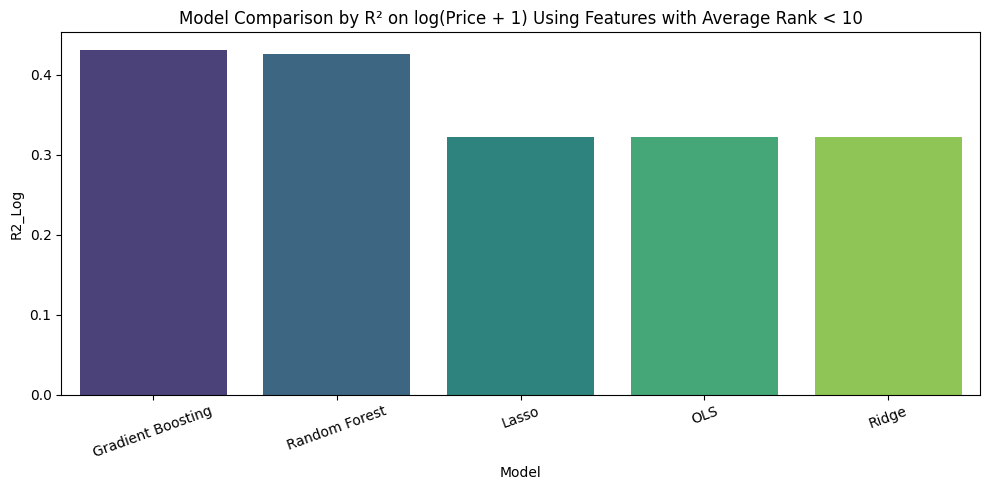

In [9]:
# Compare 5 candidate models using features with Average_Rank < 10 for log(Price + 1)
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

selected_features = rank_under_10_features.copy()
X_model = df[selected_features].copy()
y_model_log = np.log1p(df['Price'])

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(
    X_model, y_model_log, test_size=0.2, random_state=42
)

y_test_original = np.expm1(y_test_model)

candidate_models = {
    'OLS': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=np.logspace(-3, 3, 50)))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LassoCV(cv=5, random_state=42, max_iter=20000))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=3
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    )
}

comparison_rows = []

for model_name, model in candidate_models.items():
    model.fit(X_train_model, y_train_model)
    y_pred_log = model.predict(X_test_model)
    y_pred_original = np.expm1(y_pred_log)

    comparison_rows.append({
        'Model': model_name,
        'Feature_Count': len(selected_features),
        'R2_Log': r2_score(y_test_model, y_pred_log),
        'RMSE_Log': np.sqrt(mean_squared_error(y_test_model, y_pred_log)),
        'RMSE_Original': np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
        'MAE_Original': mean_absolute_error(y_test_original, y_pred_original)
    })

model_comparison_df = pd.DataFrame(comparison_rows)
model_comparison_df[['R2_Log', 'RMSE_Log', 'RMSE_Original', 'MAE_Original']] = model_comparison_df[
    ['R2_Log', 'RMSE_Log', 'RMSE_Original', 'MAE_Original']
].round(4)
model_comparison_df = model_comparison_df.sort_values(by=['R2_Log', 'RMSE_Original'], ascending=[False, True]).reset_index(drop=True)

best_model_name = model_comparison_df.loc[0, 'Model']

print('Selected features with Average_Rank < 10:')
print(selected_features)
print(f'Total selected features: {len(selected_features)}')
print('\nModel comparison table:')
display(model_comparison_df)
print(f'\nBest model based on highest R2_Log and lowest error: {best_model_name}')

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison_df, x='Model', y='R2_Log', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison by R² on log(Price + 1) Using Features with Average Rank < 10')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Summary of Model Comparison

Using **`log(Price + 1)`** as the response variable, we selected all predictors with **average rank below 10** from the consensus feature-selection step, which resulted in **9 features**. We then compared five models: **OLS**, **Ridge**, **Lasso**, **Random Forest**, and **Gradient Boosting**. The results show that the **tree-based models perform better than the linear models** for this dataset. In particular, **Gradient Boosting** achieved the highest $R^2$ on the log scale (**0.4383**), while **Random Forest** produced slightly lower prediction error on the original price scale. Overall, these results suggest that the relationship between the selected features and resale price is not purely linear, and that **Gradient Boosting is the best overall model** if the main goal is model fit on the transformed scale, while **Random Forest is also a strong choice** if practical prediction accuracy in original price units is emphasized.

## Final Gradient Boosting Model and Prediction Accuracy

Since **Gradient Boosting** gave the best overall fit in the model comparison, we now fit it as the final prediction model using the selected features with **average rank below 10**.

We also compare the **actual price** and **predicted price** visually to see how well the final model tracks the resale values.

Final selected features:
['Months_Since_Release', 'Condition_Score', 'Post_Recency_Log', 'Storage_Tier_Unknown', 'Storage_GB', 'Product_Origin_Unknown', 'Is_Premium_Tier', 'Original_Price_HKD', 'Days_Since_Posted']

Gradient Boosting prediction accuracy:


,Metric,Value
0,R2_Log,0.4313
1,RMSE_Log,1.1373
2,RMSE_Original,2617.7274
3,MAE_Original,1391.9813



Sample of actual vs predicted prices:


,Actual_Price,Predicted_Price,Residual
0,6200.0,1574.06,4625.94
1,2880.0,2998.83,-118.83
2,3300.0,692.65,2607.35
3,800.0,1089.48,-289.48
4,7000.0,5366.80,1633.20
5,2000.0,1646.17,353.83
6,350.0,725.42,-375.42
7,1280.0,1427.85,-147.85
8,1680.0,969.33,710.67
9,5598.0,2982.00,2616.00


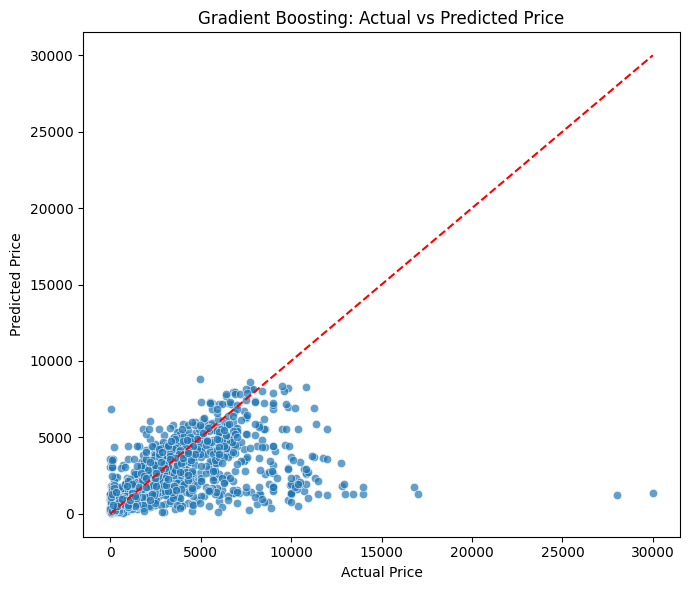

In [10]:
# Final Gradient Boosting model using features with Average_Rank < 10
final_selected_features = rank_under_10_features.copy()
X_final = df[final_selected_features].copy()
y_final_log = np.log1p(df['Price'])

X_train_final, X_test_final, y_train_final_log, y_test_final_log = train_test_split(
    X_final, y_final_log, test_size=0.2, random_state=42
)

final_log_gb = GradientBoostingRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)
final_log_gb.fit(X_train_final, y_train_final_log)

y_pred_final_log = final_log_gb.predict(X_test_final)
y_test_original = np.expm1(y_test_final_log)
y_pred_final = np.expm1(y_pred_final_log)

final_accuracy = pd.DataFrame({
    'Metric': ['R2_Log', 'RMSE_Log', 'RMSE_Original', 'MAE_Original'],
    'Value': [
        r2_score(y_test_final_log, y_pred_final_log),
        np.sqrt(mean_squared_error(y_test_final_log, y_pred_final_log)),
        np.sqrt(mean_squared_error(y_test_original, y_pred_final)),
        mean_absolute_error(y_test_original, y_pred_final)
    ]
})
final_accuracy['Value'] = final_accuracy['Value'].round(4)

prediction_results = pd.DataFrame({
    'Actual_Price': y_test_original.values,
    'Predicted_Price': y_pred_final
}).reset_index(drop=True)
prediction_results['Residual'] = prediction_results['Actual_Price'] - prediction_results['Predicted_Price']
prediction_results = prediction_results.round(2)

print('Final selected features:')
print(final_selected_features)
print('\nGradient Boosting prediction accuracy:')
display(final_accuracy)
print('\nSample of actual vs predicted prices:')
display(prediction_results.head(10))

plt.figure(figsize=(7, 6))
sns.scatterplot(data=prediction_results, x='Actual_Price', y='Predicted_Price', alpha=0.7)
min_val = min(prediction_results['Actual_Price'].min(), prediction_results['Predicted_Price'].min())
max_val = max(prediction_results['Actual_Price'].max(), prediction_results['Predicted_Price'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title('Gradient Boosting: Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()

## Limitations of the Dataset and Modeling Process

This analysis has several important limitations. First, the **original dataset** is based on resale listings rather than controlled market transactions, so the observed price may reflect seller behavior, negotiation strategy, missing listing details, or temporary market conditions instead of the true market value of the phone. Second, the dataset likely omits useful predictors such as battery health, detailed cosmetic condition, warranty status, repair quality, bundled items, seller reputation, and local demand, so the models are built with incomplete information. Third, the data may contain measurement noise, inconsistent listing practices, and possible outliers, which can reduce model stability.

There are also limitations in the **modeling process**. The feature selection step is data-driven, so the selected variables may change if the sample changes. The analysis uses a single train-test split, which is simple but does not fully measure how stable the model is across repeated samples. Even after using `log(Price + 1)`, the final model explains only part of the variation in price, so prediction uncertainty remains substantial. In addition, tree-based models such as Gradient Boosting improve prediction performance but are less interpretable than standard linear regression. Therefore, the final model should be viewed as a useful predictive tool for this dataset, not as a complete explanation of all factors that determine resale phone price.

In [11]:
import joblib
import pickle

joblib.dump(final_log_gb, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

model_metrics = {
    'Gradient Boosting': {
        'r2_log': 0.4383,
        'rmse_log': 1.1303,
        'rmse_original': 2523.6084,
        'mae_original': 1356.0608
    }
}
with open('model_metrics.pkl', 'wb') as f:
    pickle.dump(model_metrics, f)

NameError: name 'scaler' is not defined